<a href="https://colab.research.google.com/github/Conor-04/European-Gas-Storage-Monitor/blob/main/Gas_Model_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# European Gas Balance — Storage Monitor & Spread View

A daily-updating model of European gas fundamentals. The core is a storage monitor for the five largest EU storage systems (DE, FR, IT, NL, AT, comes to roughly 73% of EU working gas volume), each benchmarked against its own seasonal history. Around it sits a data foundation consisting of Norwegian pipeline supply, LNG send-out, weather (HDD/CDD) and the TTF front-month price.

**Thesis:** storage level, pace, and position vs the seasonal norm are fundamental to the European gas market, this notebook quantifies the storage side, models the two biggest suppliers (Norwegian pipe, LNG send-out), and closes with a view on the TTF summer–winter spread.

**Structure**
- **0 · Setup** — configuration and shared helpers
- **1 · Data layer** — every source pulled, cleaned, cached, and merged into one daily frame
- **2 · Storage monitor** — engine, EU-5 roll-up, briefs, per-country drill-downs
- **3 · Storage ↔ price** — why storage primarily influences the curve and not the outright price
- **4 · The view** — evidence block and desk note: the storage-to-spread call

**Run order:** add a free GIE API key as the Colab secret `AGSI_KEY` (one key covers both AGSI+ storage and ALSI LNG), then run top to bottom.

*Key design choices — median-not-mean benchmarking, ±7-day windowed pooling, capacity-weighted aggregation, a like-for-like pace z-score — are documented at the relevant cells.*

## 0 · Setup

Imports, configuration, and shared helpers. Parameters such as countries, fill targets and weather hubs placed here.

In [ ]:
!pip install -q eurogastp yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.9/420.9 kB 9.3 MB/s eta 0:00:00


In [ ]:
import os, time, requests
from datetime import date
from dataclasses import dataclass
from typing import Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import userdata

# ---- API (one GIE key covers AGSI+ storage and ALSI LNG) ----
GIE_KEY     = userdata.get("AGSI_KEY")
GIE_HEADERS = {"x-key": GIE_KEY}
AGSI_BASE   = "https://agsi.gie.eu/api"
ALSI_BASE   = "https://alsi.gie.eu/api"

# ---- analysis windows ----
START       = "2017-01-01"   # default history floor (AGSI / ALSI / weather / TTF)
WINDOW      = 7              # +/- days pooled for seasonal bands and reads
PACE_WINDOW = 30            # trailing days for the cumulative pace measures

# ---- storage grid (EU-5, ~73% of EU working gas volume) ----
# fill_target: DE = 0.70 is the legislated aggregate (80% standard / 45% for six named
# facilities) under the Gas Storage Level Requirements Ordinance, accepted by the EU as
# compliant. Others = 0.80, the lower bound of the EU's 80-90% flexibility band (2025
# amendment) that capitals were steered toward to avoid summer price spikes. Absent a
# country-specific legislated figure, 0.80 is a deliberate floor assumption, not a fact.
EU_LO, EU_HI = 0.80, 0.90
COUNTRY_CONFIG = {
    "DE": {"name": "Germany",     "role": "seasonal",                 "fill_target": 0.70},
    "FR": {"name": "France",      "role": "seasonal",                 "fill_target": 0.80},
    "IT": {"name": "Italy",       "role": "seasonal",                 "fill_target": 0.80},
    "NL": {"name": "Netherlands", "role": "fast-cycle",               "fill_target": 0.80},
    "AT": {"name": "Austria",     "role": "seasonal (export-linked)", "fill_target": 0.80},
}

# ---- LNG regas importers feeding the EU-5 balance (German terminals from 2023) ----
# ES is deliberately excluded despite being major importer: Iberian send-out is interconnection-capped into France
# limiting what can reach the EU-5 grid, inclusion would distort numbers for the storage grid. BE present as Zeebrugge is a
# transit gateway wired into the NW-European grid that feeds the five.
LNG_COUNTRIES = ["FR", "NL", "IT", "BE", "DE"]
LNG_START     = {"DE": "2023-01-01"}

# ---- weather demand centres, gas-demand-weighted to one EU HDD ----
HUBS = {
    "Cologne": (50.94, 6.96, "DE"), "Munich": (48.14, 11.58, "DE"), "Hamburg": (53.55, 9.99, "DE"),
    "Paris": (48.85, 2.35, "FR"),   "Lyon": (45.76, 4.84, "FR"),
    "Milan": (45.46, 9.19, "IT"),   "Rome": (41.90, 12.50, "IT"),
    "Amsterdam": (52.37, 4.90, "NL"), "Vienna": (48.21, 16.37, "AT"),
}
COUNTRY_GAS_WEIGHT = {"DE": 0.40, "IT": 0.24, "FR": 0.20, "NL": 0.11, "AT": 0.05}
HDD_BASE = 15.5   # heating-degree-day threshold (degC)
CDD_BASE = 22.0   # cooling-degree-day threshold (degC); summer power-burn / AC demand proxy

# ---- Norwegian pipeline supply (ENTSOG) ----
NOR_START      = "2022-01-01"        # true ENTSOG physical-flow floor for these points
NORWAY_EXCLUDE = {
    "NorthSeaNODK",                    # Baltic Pipe (NO->DK->PL): out of scope + late-2022 composition break
    "EmdenNPTNODE", "EmdenNPTNONL",    # Norpipe points: no ENTSOG data (source of warnings)
}

# ---- cache filenames ----
CACHE = {"storage": "eu_storage.csv", "lng": "lng_sendout.csv", "weather": "weather_dd.csv",
         "ttf": "ttf_frontmonth.csv", "norway": "norway_supply.csv"}

CY = None   # current data year; set after the storage pull, used by the plotting helpers

In [ ]:
def fetch_json(base, params=None, headers=None, retries=3, timeout=30):
    """GET with exponential backoff so one transient blip doesn't lose a long pull."""
    for attempt in range(retries):
        try:
            r = requests.get(base, params=params, headers=headers, timeout=timeout)
            r.raise_for_status()
            return r.json()
        except requests.RequestException:
            if attempt == retries - 1:
                raise
            time.sleep(2 ** attempt)   # 1s, 2s, 4s


def load_or_build(path, builder, parse_dates=("date",), force=False):
    """Return today's cache if fresh, else build via builder(), cache, and return.
    Keeps daily runs fast without ever serving stale data across days."""
    if not force and os.path.exists(path) and \
       date.fromtimestamp(os.path.getmtime(path)) == date.today():
        df = pd.read_csv(path, parse_dates=list(parse_dates))
        print(f"  cache hit  {path}: {len(df)} rows")
        return df
    df = builder()
    df.to_csv(path, index=False)
    print(f"  built      {path}: {len(df)} rows")
    return df


def add_calendar(df):
    """Add year + leap-adjusted day-of-year (1-365), dropping Feb 29 so the day-of-year
    index aligns across leap and non-leap years."""
    df = df.copy()
    df["year"] = df["date"].dt.year
    leap_shift = (df["date"].dt.is_leap_year & (df["date"].dt.month > 2)).astype(int)
    df["doy"]  = df["date"].dt.dayofyear - leap_shift
    return df[~((df["date"].dt.month == 2) & (df["date"].dt.day == 29))].copy()


def _windowed_stat(ref, col, agg):
    """Vectorised +/-WINDOW day-of-year pooling that wraps the year boundary, so day 1
    pools late-December and day 365 pools early-January (~15x the obs per calendar day)."""
    base = ref[["doy", col]].dropna()
    parts = []
    for k in range(-WINDOW, WINDOW + 1):
        p = base.copy()
        p["key"] = ((base["doy"] + k - 1) % 365) + 1
        parts.append(p)
    out = pd.concat(parts, ignore_index=True).groupby("key")[col].agg(agg)
    out.index.name = "doy"
    return out.reindex(range(1, 366))


def to_xdate(doy):
    """Map day-of-year onto the current data year for plotting on a real date axis."""
    return pd.to_datetime(f"{CY}-01-01") + pd.to_timedelta(doy - 1, unit="D")

## 1 · Data layer

Every source is pulled, cleaned to a tidy frame, cached (refreshed once per day), and verified. Closes with aggregation of supply/demand layers and merging of everything onto one daily index used in the analysis phase.

**Units:** storage stock in TWh; all flows (storage net, Norwegian supply, LNG send-out) in GWh/d; weather in heating and cooling-degree-days (degC·day); price in EUR/MWh.

**Sources:** GIE AGSI+ (storage), GIE ALSI (LNG send-out), ENTSOG via `eurogastp` (Norwegian pipeline), Open-Meteo (temperature), Yahoo Finance (TTF front-month, `TTF=F`).

In [ ]:
# ============ STORAGE — GIE AGSI+ ============
def tidy_storage(rows):
    if not rows:
        raise ValueError("No storage data returned — check country code / date range / key.")
    df = pd.DataFrame(rows)[["gasDayStart", "gasInStorage", "full", "injection",
                             "withdrawal", "workingGasVolume"]]
    df.columns = ["date", "gas_twh", "full_pct", "inj_gwh", "wdl_gwh", "wgv_twh"]
    df["date"] = pd.to_datetime(df["date"])
    for c in df.columns[1:]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.sort_values("date").reset_index(drop=True)


def fetch_storage(country, start=START, end=None, size=300):
    end = end or date.today().isoformat()
    rows, page = [], 1
    while True:
        payload = fetch_json(AGSI_BASE, {"country": country, "from": start, "to": end,
                                         "size": size, "page": page}, headers=GIE_HEADERS)
        rows.extend(payload["data"])
        if page >= int(payload.get("last_page", 1)):
            break
        page += 1
    return tidy_storage(rows)


def _build_storage():
    frames = []
    for code in COUNTRY_CONFIG:
        df = fetch_storage(code); df["country"] = code
        frames.append(df)
        print(f"    {code} ({COUNTRY_CONFIG[code]['name']:11s}): {len(df):4d} rows")
    return pd.concat(frames, ignore_index=True)


eu = load_or_build(CACHE["storage"], _build_storage)
eu = add_calendar(eu)
eu["net_flow"] = eu["inj_gwh"] - eu["wdl_gwh"]

# capacity-normalise stock to each country's latest working gas volume, so the 5y level
# band compares fullness across capacity eras (e.g. Germany's WGV shifts as Rehden's
# status changed) rather than raw TWh. On the latest day gas_adj == gas_twh by construction.
wgv_latest = eu.sort_values("date").groupby("country")["wgv_twh"].last()
eu["gas_adj"] = eu["gas_twh"] * eu["country"].map(wgv_latest) / eu["wgv_twh"]
CY = int(eu["year"].max())

print("\n  freshness check:")
for code, g in eu.groupby("country"):
    span     = (g["date"].max() - g["date"].min()).days + 1
    leapdays = int(g["date"].dt.is_leap_year.groupby(g["date"].dt.year).first().sum())
    expected = span - leapdays
    flag     = "no gaps" if len(g) == expected else f"GAPS ({expected - len(g)} missing)"
    print(f"    {code}: {len(g):4d} rows -> {g['date'].max().date()}, {flag}, NaNs {g['gas_twh'].isna().sum()}")

    DE (Germany    ): 3468 rows
    FR (France     ): 3468 rows
    IT (Italy      ): 3468 rows
    NL (Netherlands): 3468 rows
    AT (Austria    ): 3468 rows
  built      eu_storage.csv: 17340 rows

  freshness check:
    AT: 3466 rows -> 2026-06-30, no gaps, NaNs 0
    DE: 3466 rows -> 2026-06-30, no gaps, NaNs 0
    FR: 3466 rows -> 2026-06-30, no gaps, NaNs 0
    IT: 3466 rows -> 2026-06-30, no gaps, NaNs 0
    NL: 3466 rows -> 2026-06-30, no gaps, NaNs 0


In [ ]:
# ============ EU-5 AGGREGATE (synthetic total: sum of absolute volumes) ============
# Sum absolute TWh across countries per gas-day, not a mean of percentages so a
# small country can't distort the aggregate. Only full-coverage days are kept.
n_countries = eu["country"].nunique()
eu_agg = (eu.groupby("date")
            .agg(gas_twh=("gas_twh", "sum"), gas_adj=("gas_adj", "sum"),
                 wgv_twh=("wgv_twh", "sum"), net_flow=("net_flow", "sum"),
                 n=("country", "nunique"))
            .reset_index())
eu_agg = eu_agg[eu_agg["n"] == n_countries].copy()
eu_agg["full_pct"] = eu_agg["gas_twh"] / eu_agg["wgv_twh"] * 100
eu_agg = add_calendar(eu_agg)
print(f"EU-5 aggregate: {len(eu_agg)} full-coverage days, "
      f"{eu_agg['date'].min().date()} -> {eu_agg['date'].max().date()}, "
      f"latest {eu_agg['gas_twh'].iloc[-1]:.0f} TWh ({eu_agg['full_pct'].iloc[-1]:.0f}% full)")

EU-5 aggregate: 3466 full-coverage days, 2017-01-01 -> 2026-06-30, latest 392 TWh (48% full)


In [ ]:
# ============ LNG SEND-OUT — GIE ALSI ============
def tidy_lng(rows):
    if not rows:
        raise ValueError("No LNG data — check country code / ALSI access.")
    recs = [{"date": r["gasDayStart"], "sendout": r.get("sendOut"),
             "lng_inv": (r.get("inventory") or {}).get("gwh")} for r in rows]
    df = pd.DataFrame(recs)
    df["date"]    = pd.to_datetime(df["date"])
    df["sendout"] = pd.to_numeric(df["sendout"], errors="coerce")
    df["lng_inv"] = pd.to_numeric(df["lng_inv"], errors="coerce")
    return df.sort_values("date").reset_index(drop=True)


def fetch_lng(country, start=START, end=None, size=300):
    end = end or date.today().isoformat()
    rows, page = [], 1
    while True:
        payload = fetch_json(ALSI_BASE, {"country": country, "from": start, "to": end,
                                         "size": size, "page": page}, headers=GIE_HEADERS)
        rows.extend(payload["data"])
        if page >= int(payload.get("last_page", 1)):
            break
        page += 1
    return tidy_lng(rows)


def lng_window(df, code):
    """Trim a country's series to its representative window (DE terminals -> 2023+)."""
    return df[df["date"] >= LNG_START.get(code, START)].copy()


def _build_lng():
    frames = []
    for code in LNG_COUNTRIES:
        df = fetch_lng(code); df["country"] = code
        frames.append(df)
        print(f"    {code}: {len(df):4d} rows -> {df['date'].max().date()}, "
              f"latest sendout {df['sendout'].iloc[-1]:.0f} GWh/d")
    return pd.concat(frames, ignore_index=True)


lng = load_or_build(CACHE["lng"], _build_lng)

    FR: 3468 rows -> 2026-06-30, latest sendout 602 GWh/d
    NL: 3468 rows -> 2026-06-30, latest sendout 647 GWh/d
    IT: 3468 rows -> 2026-06-30, latest sendout 744 GWh/d
    BE: 3468 rows -> 2026-06-30, latest sendout 232 GWh/d
    DE: 3468 rows -> 2026-06-30, latest sendout 246 GWh/d
  built      lng_sendout.csv: 17340 rows


In [ ]:
# ============ WEATHER / HEATING DEGREE DAYS — Open-Meteo ============
def _build_weather():
    lats = ",".join(str(v[0]) for v in HUBS.values())
    lons = ",".join(str(v[1]) for v in HUBS.values())
    url  = ("https://archive-api.open-meteo.com/v1/archive"
            f"?latitude={lats}&longitude={lons}&start_date={START}"
            f"&end_date={date.today().isoformat()}"
            "&daily=temperature_2m_mean&timezone=UTC")
    j = fetch_json(url, timeout=120)   # multi-location -> list, one object per coordinate
    frames = []
    for (city, (lat, lon, ctry)), loc in zip(HUBS.items(), j):
        d = pd.DataFrame({"date": pd.to_datetime(loc["daily"]["time"]),
                          "tmean": loc["daily"]["temperature_2m_mean"]}).dropna(subset=["tmean"])
        d["hdd"] = (HDD_BASE - d["tmean"]).clip(lower=0)
        d["cdd"] = (d["tmean"] - CDD_BASE).clip(lower=0)   # summer cooling / power-burn proxy
        d["city"], d["country"] = city, ctry
        frames.append(d)
        print(f"    {city:10s} ({ctry}): {len(d)} days, mean HDD {d['hdd'].mean():.1f}, "
              f"mean CDD {d['cdd'].mean():.1f}")
    return pd.concat(frames, ignore_index=True)


wx = load_or_build(CACHE["weather"], _build_weather)
# Note: the Open-Meteo archive lags real time by a few days, so the most recent
# dates carry no HDD — visible in the coverage map below and expected.

    Cologne    (DE): 3470 days, mean HDD 5.1, mean CDD 0.1
    Munich     (DE): 3470 days, mean HDD 6.6, mean CDD 0.1
    Hamburg    (DE): 3470 days, mean HDD 5.9, mean CDD 0.1
    Paris      (FR): 3470 days, mean HDD 4.5, mean CDD 0.2
    Lyon       (FR): 3470 days, mean HDD 4.5, mean CDD 0.5
    Milan      (IT): 3470 days, mean HDD 4.2, mean CDD 0.7
    Rome       (IT): 3470 days, mean HDD 2.5, mean CDD 1.1
    Amsterdam  (NL): 3470 days, mean HDD 5.2, mean CDD 0.0
    Vienna     (AT): 3470 days, mean HDD 5.7, mean CDD 0.3
  built      weather_dd.csv: 31230 rows


In [ ]:
# ============ TTF FRONT-MONTH — Yahoo Finance (TTF=F) ============
# Yahoo's TTF=F is a rough proxy series (weekday-only, occasional gaps/bad prints) — adequate
# for the §3 motivation charts; the §4 view uses exchange strip prints, not this series.
def _build_ttf():
    import yfinance as yf
    raw = yf.download("TTF=F", start=START, auto_adjust=False, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):       # newer yfinance returns a MultiIndex
        raw.columns = raw.columns.get_level_values(0)
    return (raw.reset_index()[["Date", "Close"]]
               .rename(columns={"Date": "date", "Close": "ttf_eur"}))


ttf = load_or_build(CACHE["ttf"], _build_ttf)
ttf = ttf.sort_values("date").reset_index(drop=True)
print(f"  TTF {ttf['date'].min().date()} -> {ttf['date'].max().date()}, "
      f"latest {ttf['ttf_eur'].iloc[-1]:.1f} EUR/MWh")

  built      ttf_frontmonth.csv: 2186 rows
  TTF 2017-10-23 -> 2026-07-02, latest 43.7 EUR/MWh


In [ ]:
# ============ NORWEGIAN PIPELINE SUPPLY — ENTSOG via eurogastp ============
# Norpipe is excluded by ENTSOG itself (no flow data); Baltic Pipe
# (NorthSeaNODK) is dropped as out-of-scope and a late-2022 composition break. What
# remains is metered Norwegian piped supply to NW continental Europe: Europipe (Emden
# EPT1), Dornum/NETRA, Zeebrugge, Dunkerque. History begins 2022 under current point codes.
import eurogastp.entsog as E

TOPO_PATH    = os.path.join(os.path.dirname(E.__file__), "topo", "ENTSOG_TP_Network_v3.xlsx")
topo         = E.load_topo(topo_file=TOPO_PATH)
NORWAY_EDGES = [e for e in E.get_corridors(topo)["North Sea"]
                if e not in NORWAY_EXCLUDE]   # pre-filter: no dead points, no download warnings
print("North Sea (Norway) entry points (filtered):", NORWAY_EDGES)


def _norway_total(agg):
    """Collapse the per-edge wide frame to one daily series: force numeric, drop all-NaN
    and out-of-scope routes, fill <=3-day gaps, and require near-full edge coverage before
    summing (so a partial-coverage day can't masquerade as a low-supply day)."""
    agg  = agg.sort_index().apply(pd.to_numeric, errors="coerce")
    live = agg.dropna(axis=1, how="all")
    live = live.drop(columns=[c for c in live.columns if c in NORWAY_EXCLUDE]).ffill(limit=3)
    return live.sum(axis=1, min_count=max(1, live.shape[1] - 1))


# self-healing cache: rebuild if missing, stale (not today), or the old per-edge format
need_build = not (os.path.exists(CACHE["norway"]) and
                  date.fromtimestamp(os.path.getmtime(CACHE["norway"])) == date.today())
if not need_build:
    nor = pd.read_csv(CACHE["norway"], parse_dates=["date"])
    if "norway_gwh_d" not in nor.columns:
        need_build = True
    else:
        print(f"  cache hit  {CACHE['norway']}: {len(nor)} rows -> {nor['date'].max().date()}")

if need_build:
    start_d, end_d = pd.to_datetime(NOR_START).date(), date.today()
    E.download_entsog_tp(start_date=start_d, end_date=end_d, topo=topo, edges=NORWAY_EDGES,
                         indicators=["Physical Flow"], max_points_per_request=8, delay=1)
    raw  = E.load_raw()
    perd = E.reindex_and_periodize(raw, start_d, end_d)
    agg  = E.select_and_aggregate(NORWAY_EDGES, topo, perd, indicator="Physical Flow")

    print("\n  per-edge coverage:")
    for c in agg.columns:
        s = agg[c].dropna()
        msg = (f"{s.index.min().date()} -> {s.index.max().date()} "
               f"({len(s)} days, mean {s.mean():.0f} GWh/d)") if len(s) else "NO DATA"
        print(f"    {c:18s} {msg}")

    nor = _norway_total(agg).rename("norway_gwh_d").reset_index()
    nor.columns = ["date", "norway_gwh_d"]
    nor.to_csv(CACHE["norway"], index=False)
    print(f"\n  Norway supply: {len(nor)} rows -> {nor['date'].max().date()}, "
          f"latest {nor['norway_gwh_d'].iloc[-1]:.0f} GWh/d (mean {nor['norway_gwh_d'].mean():.0f})")

North Sea (Norway) entry points (filtered): ['DunkerqueNOFR', 'EmdenEPT1NODE', 'ZeebruggeNOBE', 'EmdenEPT1NONL', 'DornumNODE']
Period from 2026-01-01 until 2026-07-02


  0%|          | 0/5 [00:00<?, ?it/s]

Period from 2025-01-01 until 2025-12-31


  0%|          | 0/5 [00:00<?, ?it/s]

Period from 2024-01-01 until 2024-12-31


...

  0%|          | 0/5 [00:00<?, ?it/s]

Done
Loading data from ENTSOG_TP_data_2026-07-02...


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/eurogastp/entsog.py:765: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ind = pd.concat([ind, dfv])



  per-edge coverage:
    DornumNODE         2022-01-01 -> 2026-07-01 (1643 days, mean 608 GWh/d)
    DunkerqueNOFR      2022-01-01 -> 2026-06-30 (1642 days, mean 463 GWh/d)
    EmdenEPT1NODE      2022-01-01 -> 2026-07-02 (1644 days, mean 306 GWh/d)
    EmdenEPT1NONL      2022-01-01 -> 2026-07-01 (1643 days, mean 283 GWh/d)
    ZeebruggeNOBE      2022-01-01 -> 2026-06-30 (1640 days, mean 461 GWh/d)

  Norway supply: 1644 rows -> 2026-07-02, latest 2126 GWh/d (mean 2120)


In [ ]:
if "agg" not in globals():
    raw  = E.load_raw()
    perd = E.reindex_and_periodize(raw, pd.to_datetime(NOR_START).date(), date.today())
    agg  = E.select_and_aggregate(NORWAY_EDGES, topo, perd, indicator="Physical Flow")

a = agg.copy()
a.index = pd.to_datetime(a.index)

print("per-edge coverage by year:")
cov = a.groupby(a.index.year).count()
print(cov.to_string())

print("\nper-edge annual mean (GWh/d):")
print(a.groupby(a.index.year).mean().round(0).to_string())

print("\nedges with any gaps, by year:")
expected = a.groupby(a.index.year).size()
for yr in cov.index:
    short = {c: int(expected[yr] - cov.loc[yr, c]) for c in cov.columns
             if cov.loc[yr, c] < expected[yr] - 3}   # >3 missing days
    if short:
        print(f"  {yr}: {short}")

per-edge coverage by year:
edge  DornumNODE  DunkerqueNOFR  EmdenEPT1NODE  EmdenEPT1NONL  ZeebruggeNOBE
date                                                                        
2022         365            365            365            365            365
2023         365            365            365            365            365
2024         366            366            366            366            366
2025         365            365            365            365            363
2026         182            181            183            182            181

per-edge annual mean (GWh/d):
edge  DornumNODE DunkerqueNOFR EmdenEPT1NODE EmdenEPT1NONL ZeebruggeNOBE
date                                                                    
2022  711.254322    527.453733    295.469609    353.516628    467.675841
2023  591.922566    409.105081    281.084574    293.731633    450.760586
2024   525.97898    470.780662    305.905552    296.047844    473.414613
2025  581.498314    436.300493    334.

### Unified daily frame

The supply/demand layers are aggregated to EU totals and merged with storage net flow, Norwegian supply and TTF onto one daily index. `daily` is the single input to the analysis phase and is saved to `daily_foundation.csv` so that phase can load it without re-pulling. Coverage varies by column and is shown below.

In [ ]:
# ============ AGGREGATE THE LAYERS -> UNIFIED DAILY FRAME ============
# LNG: sum send-out across importers, each trimmed to its representative window, with a
# coverage guard (same standard as the Norway aggregation): a day only counts if the full
# panel reported, 4 members before the German terminals enter in 2023, 5 after. Without
# this, a partial-coverage day sums low and inaccurately appears as an LNG collapse.
_l = (pd.concat([lng_window(lng[lng["country"] == c], c) for c in LNG_COUNTRIES])
        .groupby("date")["sendout"].agg(["sum", "count"]))
_expected = np.where(_l.index >= pd.Timestamp(LNG_START["DE"]),
                     len(LNG_COUNTRIES), len(LNG_COUNTRIES) - 1)
lng_eu = _l["sum"].where(_l["count"] >= _expected).rename("lng_gwh_d")

# Weather: city -> country mean, then gas-demand-weighted to one EU HDD series. Days with
# any country missing are masked via a plain sum over NaNs, fabricates zero-HDD days on the
# Open-Meteo lag tail.
_w       = pd.Series(COUNTRY_GAS_WEIGHT)
hdd_ctry = wx.groupby(["date", "country"])["hdd"].mean().unstack("country")
hdd_eu   = (hdd_ctry.mul(_w).sum(axis=1)
              .where(hdd_ctry[list(_w.index)].notna().all(axis=1)).rename("hdd_eu"))
cdd_ctry = wx.groupby(["date", "country"])["cdd"].mean().unstack("country")
cdd_eu   = (cdd_ctry.mul(_w).sum(axis=1)
              .where(cdd_ctry[list(_w.index)].notna().all(axis=1)).rename("cdd_eu"))

# Merge everything onto one daily index (storage net flow is the EU-5 total)
daily = (eu_agg.set_index("date")[["net_flow", "gas_twh", "full_pct"]]
               .rename(columns={"net_flow": "storage_net_gwh_d", "gas_twh": "storage_twh"})
           .join(nor.set_index("date")["norway_gwh_d"], how="outer")
           .join(lng_eu, how="outer")
           .join(hdd_eu, how="outer")
           .join(cdd_eu, how="outer")
           .join(ttf.set_index("date")["ttf_eur"], how="outer")
           .sort_index())

print("=== DATA INVENTORY ===")
for name, df in [("storage (eu)", eu), ("eu_agg", eu_agg), ("lng", lng),
                 ("weather (wx)", wx), ("ttf", ttf), ("norway (nor)", nor)]:
    print(f"  {name:14s} {len(df):5d} rows, {df['date'].min().date()} -> {df['date'].max().date()}")

print(f"\n  unified `daily`: {len(daily)} rows, {daily.index.min().date()} -> {daily.index.max().date()}")
print("\n  column coverage (fraction non-null):")
print(daily.notna().mean().round(2).to_string())
print("\n  tail:")
print(daily.tail().round(1).to_string())

daily.to_csv("daily_foundation.csv")   # persist the handoff for the analysis phase
print("\n  saved -> daily_foundation.csv")

=== DATA INVENTORY ===
  storage (eu)   17330 rows, 2017-01-01 -> 2026-06-30
  eu_agg          3466 rows, 2017-01-01 -> 2026-06-30
  lng            17340 rows, 2017-01-01 -> 2026-06-30
  weather (wx)   31230 rows, 2017-01-01 -> 2026-07-02
  ttf             2186 rows, 2017-10-23 -> 2026-07-02
  norway (nor)    1644 rows, 2022-01-01 -> 2026-07-02

  unified `daily`: 3470 rows, 2017-01-01 -> 2026-07-02

  column coverage (fraction non-null):
storage_net_gwh_d    1.00
storage_twh          1.00
full_pct             1.00
norway_gwh_d         0.47
lng_gwh_d            1.00
hdd_eu               1.00
cdd_eu               1.00
ttf_eur              0.63

  tail:
            storage_net_gwh_d  storage_twh  full_pct  norway_gwh_d  lng_gwh_d  hdd_eu  cdd_eu  ttf_eur
date                                                                                                  
2026-06-28             2690.0        388.8      47.5        2344.8     2049.4     0.0     6.0      NaN
2026-06-29             1852.1  

## 2 · Storage monitor

`analyse()` runs the same self-calibrating metrics on each country, measuring it against its own 5-year history so one function serves five structurally different storage systems. It returns a typed `CountryResult` so results compose cleanly across countries.

**Key design choices**
- Level benchmarking is **capacity-normalised** (each historical stock rescaled to the latest working gas volume), so the band compares fullness across capacity eras, not raw TWh.
- The seasonal band uses ±7-day windowed pooling (~75 obs per calendar day, not 5) for stable quantiles, and reads off the **median**, which accounts for the upward bias caused by the 2022–24 crisis.
- Pace is carried as a **ratio** (for projection scaling) and a **z-score** (for the read). The z-score standardises the trailing-30-day mean against the historical distribution.

In [ ]:
@dataclass
class CountryResult:
    code: str
    name: str
    role: str
    fill_target: Optional[float]
    asof_date: object
    asof_gas: float
    asof_full: float
    pctile: float            # tightness vs own 5y range, this date
    dev_twh: float           # vs own 5y median
    gap_min: float           # vs own 5y floor
    net_7d: float            # 7d net flow, GWh/d
    net_30d: float           # 30d net flow, GWh/d (season detection)
    season: str              # "injection" or "withdrawal", from net_30d
    pace_ratio: float        # current refill / seasonal-norm refill (nan near season turns)
    pace_z: float            # trailing-30d mean vs own historical distribution, in SDs
    inj_7d: float            # 7d gross injection, GWh/d
    wdl_7d: float            # 7d gross withdrawal, GWh/d
    gross_7d: float          # inj + wdl, total throughput
    churn: float             # gross / |net| — high = two-way cycling, ~1 = one-directional
    band: pd.DataFrame
    cover_typical: Optional[float] = None
    cover_stress: Optional[float] = None


def analyse(code):
    cfg = COUNTRY_CONFIG[code]
    d   = eu[eu["country"] == code].sort_values("date").reset_index(drop=True)
    cy  = int(d["year"].max())
    ref = d[d["year"].isin(range(cy - 5, cy))]

    # seasonal band — windowed pooling (wraps year-end)
    band = pd.DataFrame({
        "lo":     _windowed_stat(ref, "gas_adj", "min"),
        "q25":    _windowed_stat(ref, "gas_adj", lambda s: s.quantile(.25)),
        "median": _windowed_stat(ref, "gas_adj", "median"),
        "q75":    _windowed_stat(ref, "gas_adj", lambda s: s.quantile(.75)),
        "hi":     _windowed_stat(ref, "gas_adj", "max"),
    }).reset_index()

    # as-of = latest valid reading; level metrics vs own pooled history for this date
    a    = d[d["gas_twh"].notna()].iloc[-1]
    adoy = int(a["doy"])
    aval = a["gas_adj"]                                   # capacity-normalised vs adjusted history
    rs   = ref.loc[ref["doy"].between(adoy - WINDOW, adoy + WINDOW), "gas_adj"]
    pctile = (rs < aval).mean() * 100 if len(rs) else float("nan")
    dev    = aval - rs.median() if len(rs) else float("nan")
    gapmin = aval - rs.min()    if len(rs) else float("nan")

    # flow series: net + gross injection/withdrawal
    d = d.copy()
    d["net_7d"]  = d["net_flow"].rolling(7,  min_periods=4).mean()
    d["net_30d"] = d["net_flow"].rolling(30, min_periods=15).mean()
    d["inj_7d"]  = d["inj_gwh"].rolling(7, min_periods=4).mean()
    d["wdl_7d"]  = d["wdl_gwh"].rolling(7, min_periods=4).mean()
    arow   = d[d["date"] == a["date"]].iloc[0]
    season = "injection" if arow["net_30d"] > 0 else "withdrawal"

    inj_7d, wdl_7d = arow["inj_7d"], arow["wdl_7d"]
    gross = inj_7d + wdl_7d
    net   = inj_7d - wdl_7d
    churn = gross / abs(net) if abs(net) > 1 else float("nan")

    # pace ratio (projection scaling): current refill vs the seasonal-median refill
    norm_median  = _windowed_stat(ref, "net_flow", "median")
    rec          = d[d["date"] <= a["date"]].tail(PACE_WINDOW + 1)
    rec_doys     = rec["doy"].iloc[:-1]
    added_actual = rec["gas_twh"].iloc[-1] - rec["gas_twh"].iloc[0]
    added_norm   = norm_median.reindex(rec_doys).sum() / 1000
    pace_ratio   = added_actual / added_norm if abs(added_norm) > 0.5 else float("nan")

    # pace z-score — median + robust (MAD) scale, matching the level band so the 2022–24
    # crisis refill can't inflate the denominator and flatten signals. Numerator is
    # the same 30d-mean net_flow statistic as the pool.
    cur_daily = d.loc[d["date"] <= a["date"], "net_flow"].tail(PACE_WINDOW).mean()
    rs2 = ref.sort_values("date").copy()
    rs2["roll30"] = rs2["net_flow"].rolling(PACE_WINDOW, min_periods=PACE_WINDOW // 2).mean()
    pool = rs2.loc[rs2["doy"].between(adoy - WINDOW, adoy + WINDOW), "roll30"].dropna()
    if len(pool) > 5:
        med    = pool.median()
        scale  = (pool - med).abs().median() * 1.4826      # robust SD estimate
        pace_z = (cur_daily - med) / scale if scale > 0 else float("nan")
    else:
        pace_z = float("nan")

    # days of cover: stock / a high-percentile own winter draw (resilience proxy; assumes
    # constant deliverability and storage-only demand, most telling early in winter)
    winter = ref[ref["date"].dt.month.isin([12, 1, 2]) & (ref["wdl_gwh"] > 0)]["wdl_gwh"]
    if len(winter) > 30:
        cover_typical = a["gas_twh"] * 1000 / winter.quantile(0.85)
        cover_stress  = a["gas_twh"] * 1000 / winter.quantile(0.97)
    else:
        cover_typical = cover_stress = float("nan")

    return CountryResult(
        code=code, name=cfg["name"], role=cfg["role"], fill_target=cfg["fill_target"],
        asof_date=a["date"], asof_gas=a["gas_twh"], asof_full=a["full_pct"],
        pctile=pctile, dev_twh=dev, gap_min=gapmin,
        net_7d=arow["net_7d"], net_30d=arow["net_30d"], season=season,
        pace_ratio=pace_ratio, pace_z=pace_z,
        inj_7d=inj_7d, wdl_7d=wdl_7d, gross_7d=gross, churn=churn,
        band=band, cover_typical=cover_typical, cover_stress=cover_stress,
    )


results = {code: analyse(code) for code in COUNTRY_CONFIG}

print(f"{'':4}{'full%':>7}{'pctile':>8}{'dev':>8}{'pace_z':>8}{'inj':>7}{'wdl':>7}{'churn':>7}")
for r in results.values():
    ch = "  n/a" if pd.isna(r.churn) else f"{r.churn:.1f}"
    print(f"{r.code:4}{r.asof_full:7.0f}{r.pctile:8.0f}{r.dev_twh:+8.0f}{r.pace_z:+8.1f}"
          f"{r.inj_7d:7.0f}{r.wdl_7d:7.0f}{ch:>7}")

      full%  pctile     dev  pace_z    inj    wdl  churn
DE       42      12     -48    -0.5    896      8    1.0
FR       49      11     -17    -2.7    411    183    2.6
IT       67      37      -8    +0.1    475     29    1.1
NL       26       0     -41    -0.1    373     23    1.1
AT       54      40     -10    -0.1    251     10    1.1


### EU-5 morning read

The headline figure: capacity-weighted EU-5 storage, percentile-ranked against its own past, with the deviation expressed as a tightness index including a per-country scan.

In [ ]:
# ============ EU-5 MORNING READ ============
cy_eu  = int(eu_agg["year"].max())
ref_eu = eu_agg[eu_agg["year"].isin(range(cy_eu - 5, cy_eu))]
a_eu  = eu_agg.iloc[-1]
adoy  = int(a_eu["doy"])
aval  = a_eu["gas_adj"]
rs_eu = ref_eu.loc[ref_eu["doy"].between(adoy - WINDOW, adoy + WINDOW), "gas_adj"]
eu_pctile = (rs_eu < aval).mean() * 100
eu_med    = rs_eu.median()
eu_dev    = aval - eu_med
eu_scale  = (rs_eu - eu_med).abs().median() * 1.4826    # robust SD (MAD), crisis-resistant
tightness_ix = eu_dev / eu_scale if eu_scale and eu_scale > 0 else float("nan")
# flow read: 7d mean for the level, 30d for season detection — same smoothing as the
# countries; a single day's net flow swings hundreds of GWh/d and is too noisy to headline
_f    = eu_agg.set_index("date")["net_flow"]
net7  = _f.rolling(7,  min_periods=4).mean().iloc[-1]
net30 = _f.rolling(30, min_periods=15).mean().iloc[-1]
eu_season = "injection" if net30 > 0 else "withdrawal"

print("=" * 60)
print(f"  EU-5 GAS STORAGE (~73% of EU) — {a_eu['date'].date()}")
print("=" * 60)
print(f"  Storage:       {a_eu['gas_twh']:.0f} TWh ({a_eu['full_pct']:.0f}% full), "
      f"{eu_pctile:.0f}th percentile for this date")
print(f"  vs 5y median:  {eu_dev:+.0f} TWh   |   tightness index: {tightness_ix:+.1f} sigma")
print(f"  flows:         {eu_season} at {abs(net7):.0f} GWh/d (7d mean, EU-5 total)")
print("-" * 60)
print(f"  {'':4}{'full%':>7}{'pctile':>8}{'dev':>8}{'pace_z':>8}   note")
for r in sorted(results.values(), key=lambda x: x.pctile):
    note = "<- tight" if r.pctile <= 15 else ("<- loose" if r.pctile >= 85 else "")
    print(f"  {r.code:4}{r.asof_full:7.0f}{r.pctile:8.0f}{r.dev_twh:+8.0f}{r.pace_z:+8.1f}   {note}")
print("=" * 60)

  EU-5 GAS STORAGE (~73% of EU) — 2026-06-30
  Storage:       392 TWh (48% full), 20th percentile for this date
  vs 5y median:  -98 TWh   |   tightness index: -0.5 sigma
  flows:         injection at 2153 GWh/d (7d mean, EU-5 total)
------------------------------------------------------------
        full%  pctile     dev  pace_z   note
  NL       26       0     -41    -0.1   <- tight
  FR       49      11     -17    -2.7   <- tight
  DE       42      12     -48    -0.5   <- tight
  IT       67      37      -8    +0.1   
  AT       54      40     -10    -0.1   


### Combined overview

All five countries on shared % full axes to avoid distortion from differing capacity, includes seasonal-median path. The gap between a country's solid current-year line and its dashed median is its standing vs normal, at a glance. The shaded band marks the EU 80–90% flexibility range.

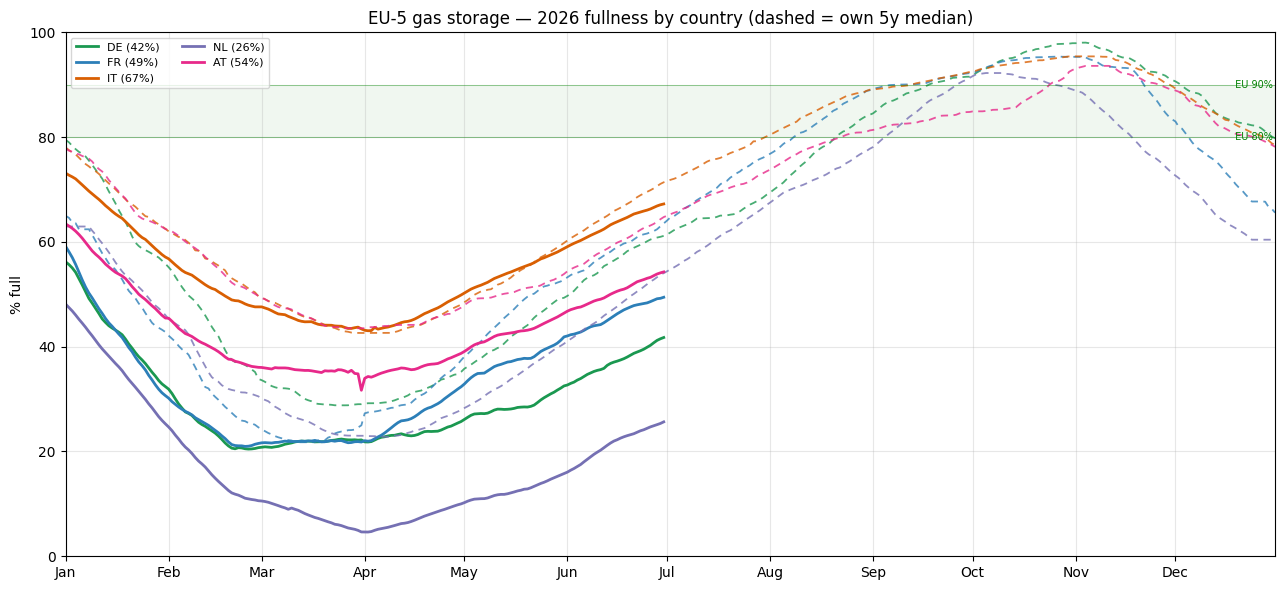

In [ ]:
# ============ COMBINED OVERVIEW — all countries, % full, shared axes ============
colors = {"DE": "#1a9850", "FR": "#2c7fb8", "IT": "#d95f02", "NL": "#7570b3", "AT": "#e7298a"}
fig, ax = plt.subplots(figsize=(13, 6))

for code, r in results.items():
    g = eu[(eu["country"] == code) & (eu["year"] == CY)].sort_values("doy")
    ax.plot(to_xdate(g["doy"]), g["gas_twh"] / g["wgv_twh"] * 100,
            color=colors[code], lw=2, label=f"{code} ({r.asof_full:.0f}%)")
    # median in %-full space: normalise each historical obs by its own day's capacity first
    cdat = eu[eu["country"] == code].copy()
    cdat["full_calc"] = cdat["gas_twh"] / cdat["wgv_twh"] * 100
    ref_c = cdat[cdat["year"].isin(range(CY - 5, CY))]
    med_full = _windowed_stat(ref_c, "full_calc", "median")
    ax.plot(to_xdate(med_full.index), med_full.values,
            color=colors[code], lw=1.3, ls=(0, (4, 3)), alpha=.8)

ax.axhspan(EU_LO * 100, EU_HI * 100, color="green", alpha=.06, zorder=0)
ax.axhline(EU_HI * 100, color="green", lw=.7, alpha=.4)
ax.axhline(EU_LO * 100, color="green", lw=.7, alpha=.4)
ax.text(to_xdate(352), EU_HI * 100, " EU 90%", color="green", va="center", fontsize=7)
ax.text(to_xdate(352), EU_LO * 100, " EU 80%", color="green", va="center", fontsize=7)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_ylabel("% full"); ax.set_ylim(0, 100)
ax.set_title(f"EU-5 gas storage — {CY} fullness by country (dashed = own 5y median)")
ax.legend(loc="upper left", fontsize=8, ncol=2); ax.grid(alpha=.3)
ax.set_xlim(to_xdate(1), to_xdate(365))
plt.tight_layout(); plt.show()

### Country briefs

Each brief is direction-neutral: every descriptor traces to a data threshold and has an opposite case, so it reads correctly whatever the situation, not just today's. The narration combines level and pace to distinguish "low but holding" from "low and losing ground."

In [ ]:
def brief(r):
    if   r.pctile < 10: tight = "exceptionally low"
    elif r.pctile < 25: tight = "well below normal"
    elif r.pctile < 40: tight = "below normal"
    elif r.pctile < 60: tight = "around normal"
    elif r.pctile < 80: tight = "above normal"
    else:               tight = "exceptionally high"

    if   pd.isna(r.pace_z): pace = "pace unclear (season turn)"
    elif r.pace_z < -1.0:   pace = "below seasonal norm"
    elif r.pace_z < -0.4:   pace = "slightly below seasonal norm"
    elif r.pace_z <= 0.4:   pace = "around seasonal norm"
    elif r.pace_z <= 1.0:   pace = "slightly above seasonal norm"
    else:                   pace = "above seasonal norm"
    verb = "injecting" if r.season == "injection" else "drawing"

    trajectory = ""
    if r.season == "injection" and r.pctile < 25 and not pd.isna(r.pace_z):
        if   r.pace_z < -0.4: trajectory = " and losing ground — below-normal injection from an already-low base"
        elif r.pace_z >  0.4: trajectory = " but refilling faster than normal"

    floor = ("below its 5-year floor for this date" if r.gap_min < 0
             else f"{r.gap_min:.0f} TWh above its 5-year floor")

    role_note = ""
    if "fast-cycle" in r.role:
        role_note = (" (note: fast-cycle storage, responds to spreads)")
    elif "export-linked" in r.role:
        role_note = (" (note: export-linked, much of its draw serves neighbouring "
                     "markets)")

    churn_note = ""
    if not pd.isna(r.churn) and r.churn > 3:
        churn_note = (f"\n  Two-way activity: gross flow {r.gross_7d:.0f} GWh/d on "
                      f"{r.net_7d:+.0f} net — cycling in both directions, not one-way fill.")

    cover_note = ""
    if not pd.isna(r.cover_typical):
        extra = " (high — large stock relative to winter draw)" if r.cover_typical > 90 else ""
        cover_note = (f"\n  Cover: ~{r.cover_typical:.0f} days of sustained winter demand "
                      f"({r.cover_stress:.0f} in a cold snap){extra}.")

    target_line = ""
    if r.fill_target is not None and r.season == "injection":
        gap = r.fill_target * 100 - r.asof_full
        target_line = (f"\n  Target: national {r.fill_target * 100:.0f}% — currently "
                       f"{abs(gap):.0f} pts {'below' if gap > 0 else 'above'} it.")

    return (
        f"{r.name.upper()} — {r.asof_date.date()}{role_note}\n"
        f"  Storage {r.asof_gas:.0f} TWh ({r.asof_full:.0f}% full), {tight} for this date "
        f"({r.pctile:.0f}th pctile), {r.dev_twh:+.0f} TWh vs 5y median, {floor}.\n"
        f"  Flows: {verb} {pace} (z {r.pace_z:+.1f}){trajectory}."
        f"{churn_note}{cover_note}{target_line}"
    )


for r in sorted(results.values(), key=lambda x: x.pctile):
    print(brief(r)); print()

NETHERLANDS — 2026-06-30 (note: fast-cycle storage, responds to spreads)
  Storage 37 TWh (26% full), exceptionally low for this date (0th pctile), -41 TWh vs 5y median, below its 5-year floor for this date.
  Flows: injecting around seasonal norm (z -0.1).
  Cover: ~34 days of sustained winter demand (27 in a cold snap).
  Target: national 80% — currently 54 pts below it.

FRANCE — 2026-06-30
  Storage 61 TWh (49% full), well below normal for this date (11th pctile), -17 TWh vs 5y median, 4 TWh above its 5-year floor.
  Flows: injecting below seasonal norm (z -2.7) and losing ground — below-normal injection from an already-low base.
  Cover: ~46 days of sustained winter demand (39 in a cold snap).
  Target: national 80% — currently 31 pts below it.

GERMANY — 2026-06-30
  Storage 103 TWh (42% full), well below normal for this date (12th pctile), -48 TWh vs 5y median, 7 TWh above its 5-year floor.
  Flows: injecting slightly below seasonal norm (z -0.5) and losing ground — below-normal

### Per-country drill-downs

Brief + fan chart + projection for each country, tightest first. Each projection is a scenario, not a forecast: it scales the seasonal-median refill shape by current pace and compares it against the level required to reach that country's national target.

NETHERLANDS — 2026-06-30 (note: fast-cycle storage, responds to spreads)
  Storage 37 TWh (26% full), exceptionally low for this date (0th pctile), -41 TWh vs 5y median, below its 5-year floor for this date.
  Flows: injecting around seasonal norm (z -0.1).
  Cover: ~34 days of sustained winter demand (27 in a cold snap).
  Target: national 80% — currently 54 pts below it.


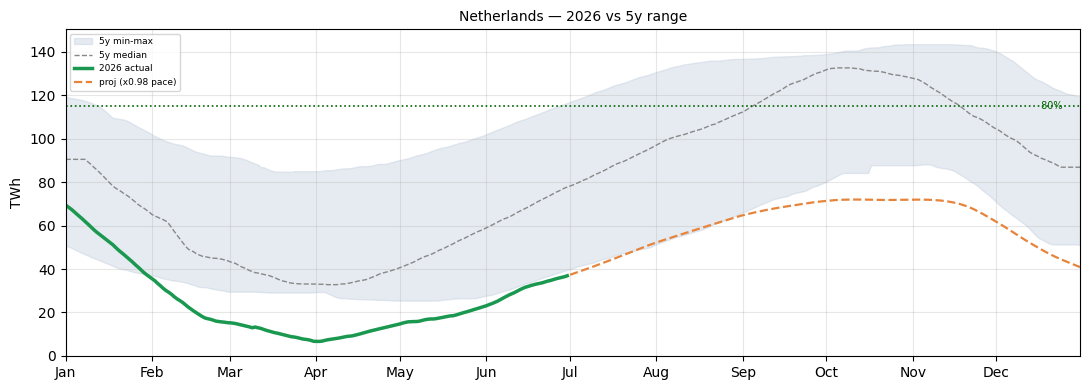


FRANCE — 2026-06-30
  Storage 61 TWh (49% full), well below normal for this date (11th pctile), -17 TWh vs 5y median, 4 TWh above its 5-year floor.
  Flows: injecting below seasonal norm (z -2.7) and losing ground — below-normal injection from an already-low base.
  Cover: ~46 days of sustained winter demand (39 in a cold snap).
  Target: national 80% — currently 31 pts below it.


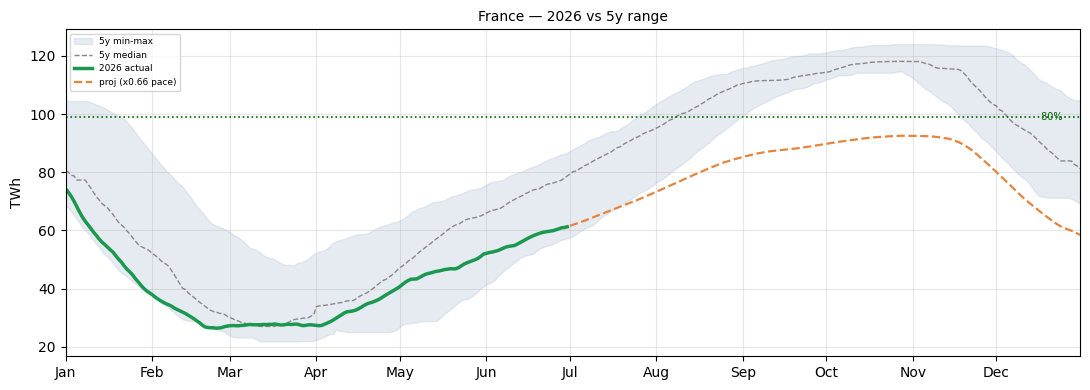


GERMANY — 2026-06-30
  Storage 103 TWh (42% full), well below normal for this date (12th pctile), -48 TWh vs 5y median, 7 TWh above its 5-year floor.
  Flows: injecting slightly below seasonal norm (z -0.5) and losing ground — below-normal injection from an already-low base.
  Cover: ~45 days of sustained winter demand (34 in a cold snap).
  Target: national 70% — currently 28 pts below it.


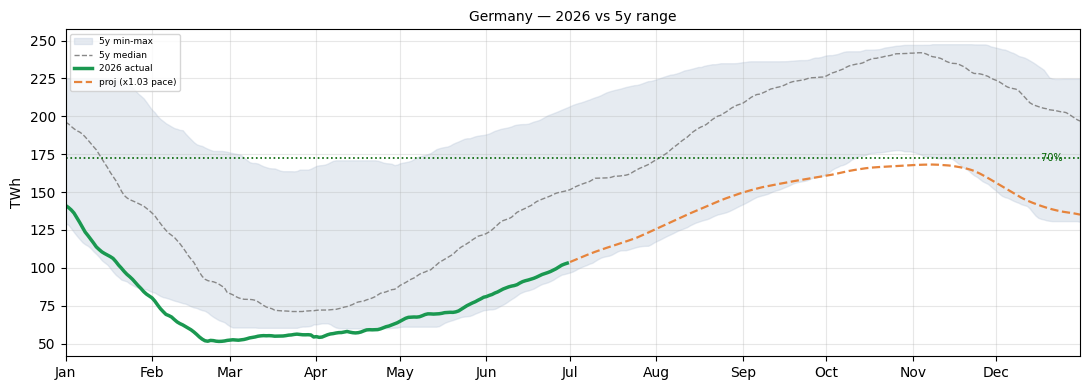


ITALY — 2026-06-30
  Storage 137 TWh (67% full), below normal for this date (37th pctile), -8 TWh vs 5y median, 23 TWh above its 5-year floor.
  Flows: injecting around seasonal norm (z +0.1).
  Cover: ~119 days of sustained winter demand (107 in a cold snap) (high — large stock relative to winter draw).
  Target: national 80% — currently 13 pts below it.


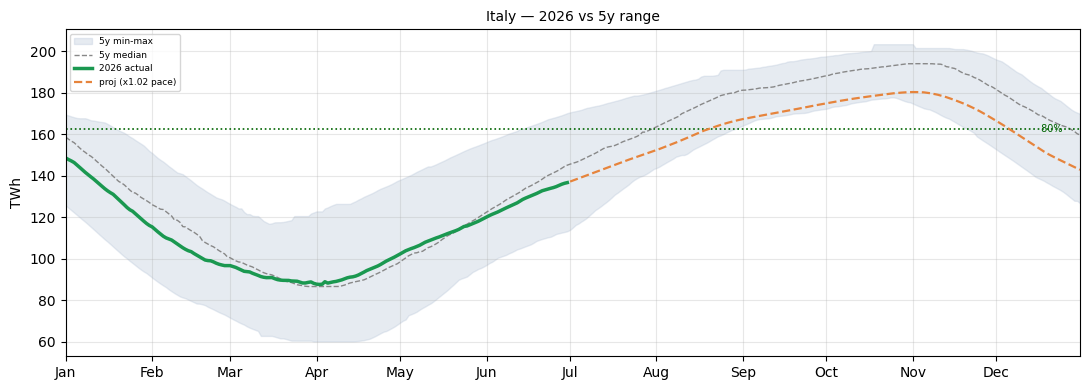


AUSTRIA — 2026-06-30 (note: export-linked, much of its draw serves neighbouring markets)
  Storage 54 TWh (54% full), around normal for this date (40th pctile), -10 TWh vs 5y median, 26 TWh above its 5-year floor.
  Flows: injecting around seasonal norm (z -0.1).
  Cover: ~84 days of sustained winter demand (64 in a cold snap).
  Target: national 80% — currently 26 pts below it.


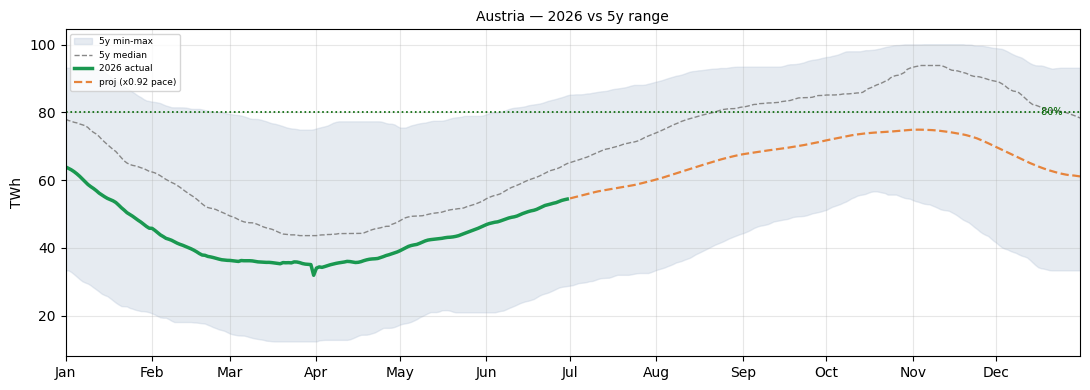

In [ ]:
def country_chart(r, ax):
    cdat = eu[eu["country"] == r.code].copy()
    wgv  = cdat["wgv_twh"].iloc[-1]

    x = to_xdate(r.band["doy"])
    ax.fill_between(x, r.band["lo"], r.band["hi"], color="#b9c7d9", alpha=.35, label="5y min-max")
    ax.plot(x, r.band["median"], color="#888", ls="--", lw=1, label="5y median")

    cur = cdat[cdat["year"] == CY].sort_values("doy")
    ax.plot(to_xdate(cur["doy"]), cur["gas_twh"], color="#1a9850", lw=2.5, label=f"{CY} actual")

    if r.fill_target is not None:
        ax.axhline(r.fill_target * wgv, color="darkgreen", ls=":", lw=1.2)
        ax.text(to_xdate(350), r.fill_target * wgv, f" {r.fill_target * 100:.0f}%",
                color="darkgreen", va="center", fontsize=7)

    # projection: seasonal shape scaled by current pace (only if pace is defined & injecting)
    if not pd.isna(r.pace_ratio) and r.season == "injection":
        ref   = cdat[cdat["year"].isin(range(CY - 5, CY))]
        sflow = _windowed_stat(ref, "net_flow", "median")
        adoy  = int(cdat[cdat["gas_twh"].notna()]["doy"].iloc[-1])
        stock, proj = r.asof_gas, []
        for dd in range(adoy + 1, 366):
            stock += max(sflow.get(dd, 0), 0) * r.pace_ratio / 1000 + min(sflow.get(dd, 0), 0) / 1000
            proj.append((dd, min(stock, wgv)))
        if proj:
            pdoy, pval = zip(*proj)
            ax.plot(to_xdate(pd.Series(pdoy)), pval, color="#e6843c", ls="--", lw=1.6,
                    label=f"proj (x{r.pace_ratio:.2f} pace)")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_xlim(to_xdate(1), to_xdate(365))
    ax.set_ylabel("TWh"); ax.set_title(f"{r.name} — {CY} vs 5y range", fontsize=10)
    ax.legend(loc="upper left", fontsize=6.5); ax.grid(alpha=.3)


for r in sorted(results.values(), key=lambda x: x.pctile):
    print(brief(r))
    fig, ax = plt.subplots(figsize=(11, 4))
    country_chart(r, ax)
    plt.tight_layout(); plt.show()
    print()

## 3 · Storage ↔ price

Storage tightness and the TTF front-month price are only loosely and unstably related: the link was strong pre-2022, broke during the crisis, and has been weak-to-negative since. The outright price is set by global factors while storage scarcity is priced in the shape of the curve, the summer–winter spread. The charts below show the storage signal this notebook builds should be tied to the spread, not the outright.

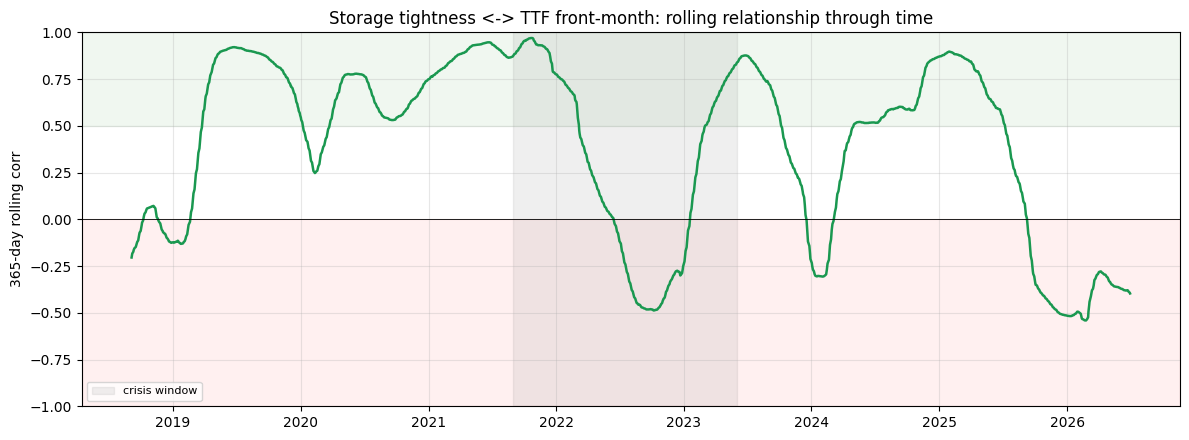

Current 365d storage-price correlation: -0.40 — regime-dependent, which is the case for moving from the outright to the spread.


In [ ]:
# full-sample EU seasonal norm -> tightness time series.
# Same construction as the morning read's tightness index, plain std would be crisis-inflated and
# compress every post-2023 reading. Sign is flipped so tighter plots upward against price.
# The norm is full-sample to show the crisis regime against all history, not to benchmark today.
eu_norm = pd.DataFrame({
    "median": _windowed_stat(eu_agg, "gas_adj", "median"),
    "mad":    _windowed_stat(eu_agg, "gas_adj",
                             lambda s: (s - s.median()).abs().median() * 1.4826),
}).reset_index()
eu_ts = eu_agg.merge(eu_norm, on="doy", how="left")
eu_ts["deficit"] = -((eu_ts["gas_adj"] - eu_ts["median"]) / eu_ts["mad"])

m = (eu_ts.merge(ttf, on="date", how="inner")
          .dropna(subset=["deficit", "ttf_eur"]).sort_values("date"))

ROLL = 365   # trailing window (~1y); 180 would show a faster-reacting view
mr = m.set_index("date")
roll_corr = mr["deficit"].rolling(f"{ROLL}D").corr(mr["ttf_eur"])
roll_corr = roll_corr.where(mr["deficit"].rolling(f"{ROLL}D").count() >= ROLL * 0.6)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(roll_corr.index, roll_corr.values, lw=1.8, color="#1a9850")
ax.axhline(0, color="k", lw=.6)
ax.axhspan(0.5, 1.0, color="green", alpha=.06)   # "strong" zone
ax.axhspan(-1.0, 0, color="red", alpha=.06)      # decoupled / inverted zone
ax.axvspan(pd.Timestamp("2021-09-01"), pd.Timestamp("2023-06-01"), color="grey", alpha=.12, label="crisis window")
ax.set_ylim(-1, 1); ax.set_ylabel(f"{ROLL}-day rolling corr")
ax.set_title("Storage tightness <-> TTF front-month: rolling relationship through time")
ax.legend(loc="lower left", fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

latest = roll_corr.dropna().iloc[-1]
print(f"Current {ROLL}d storage-price correlation: {latest:+.2f} "
      f"— regime-dependent, which is the case for moving from the outright to the spread.")

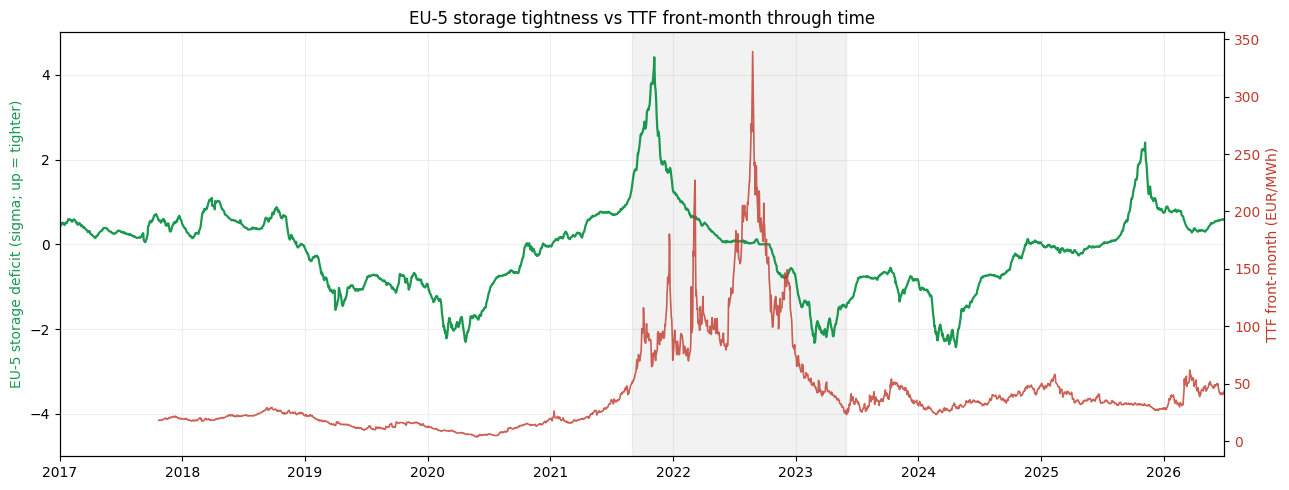

In [ ]:
# storage tightness vs TTF front-month, through time (dual axis)
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(eu_ts["date"], eu_ts["deficit"], color="#1a9850", lw=1.6)   # up = tighter
ax1.set_ylabel("EU-5 storage deficit (sigma; up = tighter)", color="#1a9850")
_lim = float(np.ceil(eu_ts["deficit"].abs().max() * 1.05))
ax1.set_ylim(-_lim, _lim)

ax2 = ax1.twinx()
ax2.plot(ttf["date"], ttf["ttf_eur"], color="#c0392b", lw=1.2, alpha=.8)
ax2.set_ylabel("TTF front-month (EUR/MWh)", color="#c0392b")
ax2.tick_params(axis="y", labelcolor="#c0392b")

ax1.axvspan(pd.Timestamp("2021-09-01"), pd.Timestamp("2023-06-01"), color="grey", alpha=.10)
ax1.set_title("EU-5 storage tightness vs TTF front-month through time")
ax1.set_xlim(eu_ts["date"].min(), eu_ts["date"].max()); ax1.grid(alpha=.2)
fig.tight_layout(); plt.show()

## 4 · Market Implication

The claim made via this model is that European storage tightness drives the TTF
summer–winter spread. The spread is what the market pays to move gas from summer
into winter, so where end-season fill lands and what's driving it there is a view on whether that spread is fairly priced.

This section states that view. It pulls the aggregate storage standing, the
supply/demand mix behind it, and the traded spread into one evidence block, and
closes with the desk note. No charts as the historical spread series needed to plot the relationship isn't openly available.

In [ ]:
# ==================== 4 · Storage to spread ====================

if "daily" not in globals():
    daily = pd.read_csv("daily_foundation.csv", parse_dates=["date"], index_col="date")

# Two reference windows, level benchmarks use the 5y median (needs the
# longer history and median accounts for crisis years); FLlow uses 2023+ as it is reflective of
# the post-crisis supply regime with Norway under current point codes and DE LNG in the panel.
ANALYSIS_START = "2023-01-01"     # flow-anomaly norm
NOV1_DOY       = 305              # 1 November — EU regulatory fill checkpoint
MIN_DRIVER     = 50               # GWh/d, filters noise

# ---- manual market prints (no open feed for seasonal strips) ----
SPREAD_ASOF = "2026-07-02"
TTF_SUMMER  = 43.89               # EUR/MWh — Summer-26 strip
TTF_WINTER  = 42.60               # EUR/MWh — Winter-26/27 strip
# Carry logic: storage capacity fee ~1.5-2.0 plus ~6 months' financing on ~43 EUR/MWh
# gas (~0.5) => ~2.5 all-in. The conclusion below is robust to this number: with the spread
# negative, "no tightness priced" holds for any carry >= 0.
CARRY       = 2.5

# ---- (a,c) anomalies vs seasonal norm: storage flow, Norway, LNG; residual = demand ----
def seasonal_anomaly(frame, col, norm_start=ANALYSIS_START):
    ref = frame.loc[frame["date"] >= norm_start, ["doy", col]].dropna().rename(columns={col: "v"})
    med = _windowed_stat(ref, "v", "median")
    return frame[col] - frame["doy"].map(med)

dd   = add_calendar(daily.reset_index())
anom = dd[["date", "doy"]].copy()
for col, short in {"storage_net_gwh_d": "storage", "norway_gwh_d": "norway",
                   "lng_gwh_d": "lng", "hdd_eu": "hdd"}.items():
    anom[short] = seasonal_anomaly(dd, col)
wk = (anom.set_index("date")[["storage", "norway", "lng", "hdd"]]
          .resample("W-MON").mean().loc[ANALYSIS_START:])

# Residual = storage − Norway − LNG. Norway and LNG are modelled because they are the swing legs where short-
# term supply variance is most applicable. Unmodelled legs (Algerian/Azeri pipe into IT,
# TurkStream, UK interconnectors, trade with the rest-of-EU 27%) largely sit inside the norm and cancel;
# off-pattern behaviour lands in the residual as minor terms alongside demand.

wk["residual"] = wk["storage"] - wk["norway"] - wk["lng"]
c4    = wk.tail(4).mean()                                     # last ~month, smoothed
r_hdd = wk["residual"].corr(wk["hdd"])                        # validation: expect ~ -0.7/-0.8
if pd.notna(r_hdd) and abs(r_hdd) < 0.5:
    print(f"*** WARNING: residual–HDD correlation {r_hdd:+.2f} — residual may no longer be "
          f"demand-dominated; check LNG/weather coverage before trusting the note ***\n")
# NB: HDD is clipped at zero, so r is in winter observations; summer residual
# anomalies read as power burn / industry / the minor terms, not heating demand.

# ---- (b) end-season read: carry today's gap-to-norm to the 1 Nov peak ----
ref_eu  = eu_agg[eu_agg["year"].isin(range(CY - 5, CY))]
med_lvl = _windowed_stat(ref_eu, "gas_adj", "median")
a       = eu_agg.iloc[-1]
eu_wgv  = a["wgv_twh"]
dev_now = a["gas_adj"] - med_lvl.get(int(a["doy"]))
fill_now = a["gas_twh"] / eu_wgv * 100
fill_eos = min(max(med_lvl.get(NOV1_DOY) + dev_now, 0), eu_wgv) / eu_wgv * 100
TARGET   = EU_HI * 100
gap      = fill_eos - TARGET

# ---- (d) traded spread vs carry ----
if (a["date"] - pd.Timestamp(SPREAD_ASOF)).days > 5:
    print(f"*** WARNING: spread prints ({SPREAD_ASOF}) lag the data ({a['date']:%Y-%m-%d}) — "
          f"refresh TTF_SUMMER / TTF_WINTER / SPREAD_ASOF ***\n")
spread = TTF_WINTER - TTF_SUMMER          # +ve = winter over summer = market pays to store
if   spread >= CARRY: curve = "scarcity premium priced"
elif spread >= 0:     curve = f"under ~{CARRY:.1f} carry — storage barely economic"
else:                 curve = "summer over winter — no tightness priced"

# ---- evidence block ----
print(f"EVIDENCE  (as of {a['date']:%Y-%m-%d}; anomalies = 4wk mean vs 2023+ norm, GWh/d)")
print(f"  storage    : {fill_now:.1f}% full, {dev_now:+.0f} TWh vs norm; "
      f"flow {c4['storage']:+.0f} ({'above' if c4['storage']>=0 else 'below'}-normal injection)")
print(f"  end-season : ~{fill_eos:.0f}% by 1 Nov on current gap "
      f"({'+' if gap>=0 else ''}{gap:.0f} pts vs {TARGET:.0f}% target)")
print(f"  supply     : Norway {c4['norway']:+.0f} | LNG {c4['lng']:+.0f}")
print(f"  demand res : {-c4['residual']:+.0f} ({'above' if c4['residual']<0 else 'below'} norm; "
      f"tracks HDD, r = {r_hdd:+.2f})")
print(f"  curve      : summer-winter {spread:+.2f} EUR/MWh vs ~{CARRY:.1f} carry ({SPREAD_ASOF})")

# ---- desk note: every line sourced from the block above; drivers gated for materiality ----
tail = [n for cond, n in [(c4["residual"] >  MIN_DRIVER, "soft demand"),
                          (c4["norway"]   >  MIN_DRIVER, "firm Norwegian flows"),
                          (c4["lng"]      >  MIN_DRIVER, "strong LNG")] if cond]
head = [n for cond, n in [(c4["lng"]      < -MIN_DRIVER, "weak LNG"),
                          (c4["norway"]   < -MIN_DRIVER, "soft Norwegian flows"),
                          (c4["residual"] < -MIN_DRIVER, "firm demand")] if cond]
fund_loose  = gap >= -2
curve_loose = spread < CARRY
wider = "wider" if curve_loose else "to re-tighten"

l1 = (f"EU-5 {fill_now:.0f}% full, {dev_now:+.0f} TWh vs norm -> ~{fill_eos:.0f}% end-season "
      f"({'above' if gap>=0 else 'short of'} the {TARGET:.0f}% target).")

if head and tail:
    verb = "offset by" if c4["storage"] >= 0 else "only partially offset by"
    l2 = f"Mix: {' and '.join(head)} {verb} {' and '.join(tail)}."
elif head: l2 = f"Mix: {' and '.join(head)}; no material offset."
elif tail: l2 = f"Mix: supply near norm, helped by {' and '.join(tail)}."
else:      l2 = "Mix: drivers within noise of norm."

l3 = (f"Curve: {spread:+.2f} vs ~{CARRY:.1f} carry -> {curve}; "
      f"{'consistent with' if fund_loose == curve_loose else 'AT ODDS with'} fundamentals.")

head_mag = abs(min(c4["lng"], 0)) + abs(min(c4["norway"], 0)) + abs(min(c4["residual"], 0))
tail_mag = max(c4["lng"], 0) + max(c4["norway"], 0) + max(c4["residual"], 0)
if head and tail and gap < 0:
    l4 = (f"Skew: one-sided — {' / '.join(head)} persists OR the offset ({' / '.join(tail)}) fades "
          f"into winter; either slips fill below ~{fill_eos:.0f}% -> spread biased {wider}.")
elif head and head_mag >= tail_mag:
    l4 = f"Skew: {' / '.join(head)} persists -> fill capped near ~{fill_eos:.0f}% -> spread biased {wider}."
elif tail:
    l4 = (f"Skew: {' / '.join(tail)} mean-reverts into winter -> fill slips below ~{fill_eos:.0f}% "
          f"-> spread biased {wider}.")
else:
    l4 = f"Skew: balanced -> fill lands near ~{fill_eos:.0f}% -> spread fair around carry."

print("\nDESK NOTE")
for l in (l1, l2, l3, l4): print(f"  * {l}")


EVIDENCE  (as of 2026-06-30; anomalies = 4wk mean vs 2023+ norm, GWh/d)
  storage    : 48.0% full, -98 TWh vs norm; flow -115 (below-normal injection)
  end-season : ~84% by 1 Nov on current gap (-6 pts vs 90% target)
  supply     : Norway +102 | LNG -20
  demand res : +197 (above norm; tracks HDD, r = -0.79)
  curve      : summer-winter -1.29 EUR/MWh vs ~2.5 carry (2026-07-02)

DESK NOTE
  * EU-5 48% full, -98 TWh vs norm -> ~84% end-season (short of the 90% target).
  * Mix: firm demand only partially offset by firm Norwegian flows.
  * Curve: -1.29 vs ~2.5 carry -> summer over winter — no tightness priced; AT ODDS with fundamentals.
  * Skew: one-sided — firm demand persists OR the offset (firm Norwegian flows) fades into winter; either slips fill below ~84% -> spread biased wider.
